<a href="https://colab.research.google.com/github/Rajeshsivamoorthy/PCA_FEL/blob/main/MD_PCA_ANA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Enter output file type (e.g., png, tif, pdf): tif
Enter DPI value (e.g., 300, 600, 900): 300


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ 2D FEL plot saved and downloaded as: 2D-FEL_plot.tif


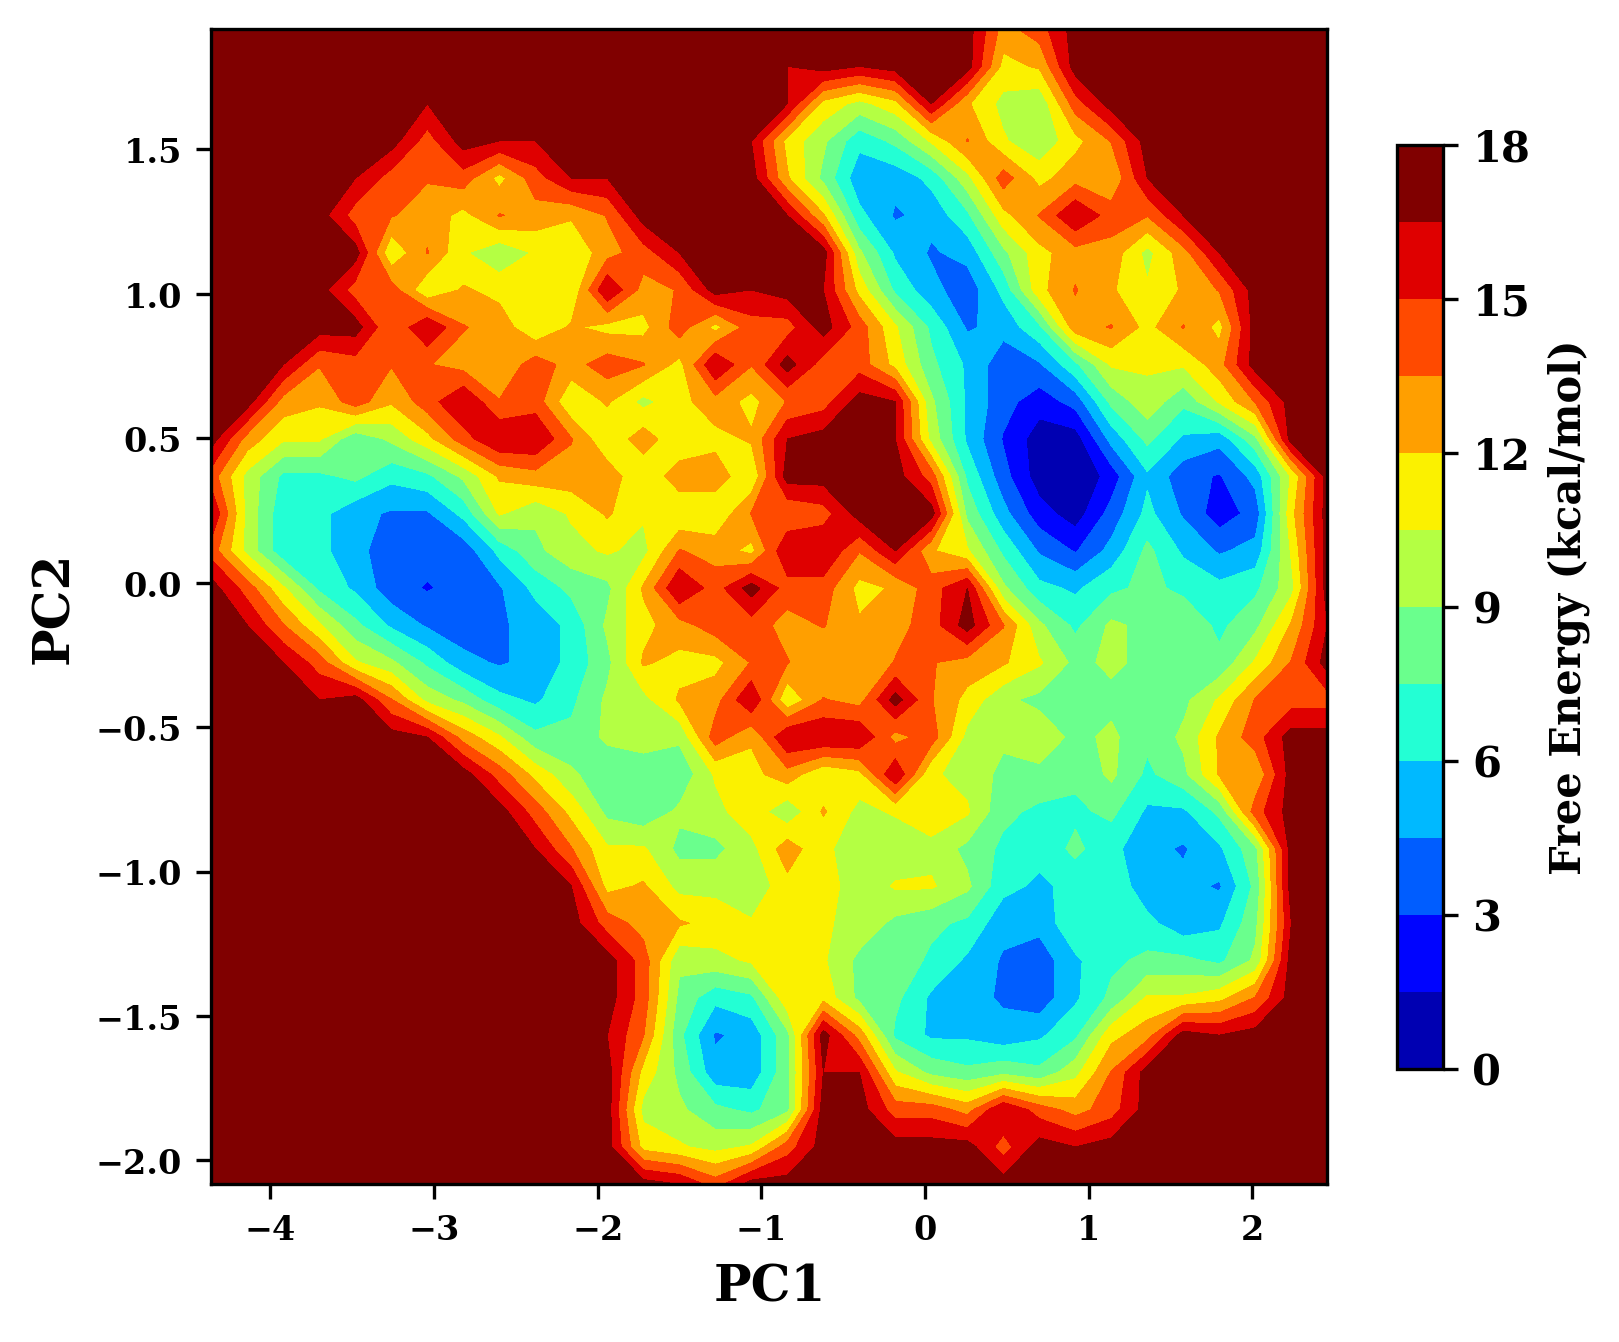

In [39]:
# ================================
# 2D PCA_FEL ANALYSIS
# ================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.interpolate import griddata
from numpy import linspace
from google.colab import files

# Set font globally for all text elements to Times New Roman and bold
plt.rcParams['font.family'] = 'DejaVu Serif'

# === File Upload ===
uploaded = files.upload()
filename = list(uploaded.keys())[0]
print(f"\n✅ File uploaded: {filename}")

# === User input for output type and DPI ===
file_type = input("\nEnter output file type (e.g., png, tif, pdf): ").strip().lower()
dpi_value = input("Enter DPI value (e.g., 300, 600, 900): ").strip()

try:
    dpi_value = int(dpi_value)
except ValueError:
    dpi_value = 300
    print("⚠️ Invalid DPI entered. Defaulting to 300.")

# === Load data ===
x, y, z = np.loadtxt(filename).T

# === Prepare grid ===
X, Y = np.unique(x), np.unique(y)
xi = linspace(min(X), max(X), len(X))
yi = linspace(min(Y), max(Y), len(Y))
X1, Y1 = np.meshgrid(xi, yi)

# === Interpolate Z values ===
Z = griddata((x, y), z, (X1, Y1), method='cubic') # Changed back to 'cubic'

# === Create 2D contour plot ===
fig, ax = plt.subplots(figsize=(6, 5), dpi=dpi_value)

# Auto scale to data
vmin_plot = np.nanmin(Z)
vmax_plot = np.nanmax(Z)

# Filled contour (clean)
cset = ax.contourf(
    X1, Y1, Z,
    cmap=cm.jet,
    vmin=vmin_plot,
    vmax=vmax_plot,
    levels=12   # clean smooth levels like uploaded image
)

# Colorbar
cbar = fig.colorbar(
    cset,
    ax=ax,
    shrink=0.8,
    aspect=20
)
cbar.set_label('Free Energy (kcal/mol)', fontsize=10)


# Axis labels
ax.set_xlabel('PC1', fontsize=12)
ax.set_ylabel('PC2', fontsize=12)
ax.tick_params(axis="x", labelsize=8)
ax.tick_params(axis="y", labelsize=8)

# === Save and Download ===
output_filename = f"2D-FEL_plot.{file_type}"
plt.savefig(output_filename, dpi=dpi_value, bbox_inches='tight')
files.download(output_filename)

print(f"\n✅ 2D FEL plot saved and downloaded as: {output_filename}")


✅ File uploaded: fel_pca_DB00303 (2).txt

Enter output file type (e.g., png, tif, pdf): tif
Enter DPI value (e.g., 300, 600, 900): 300


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Plot saved and downloaded as: 3D-FEL_plot.tif


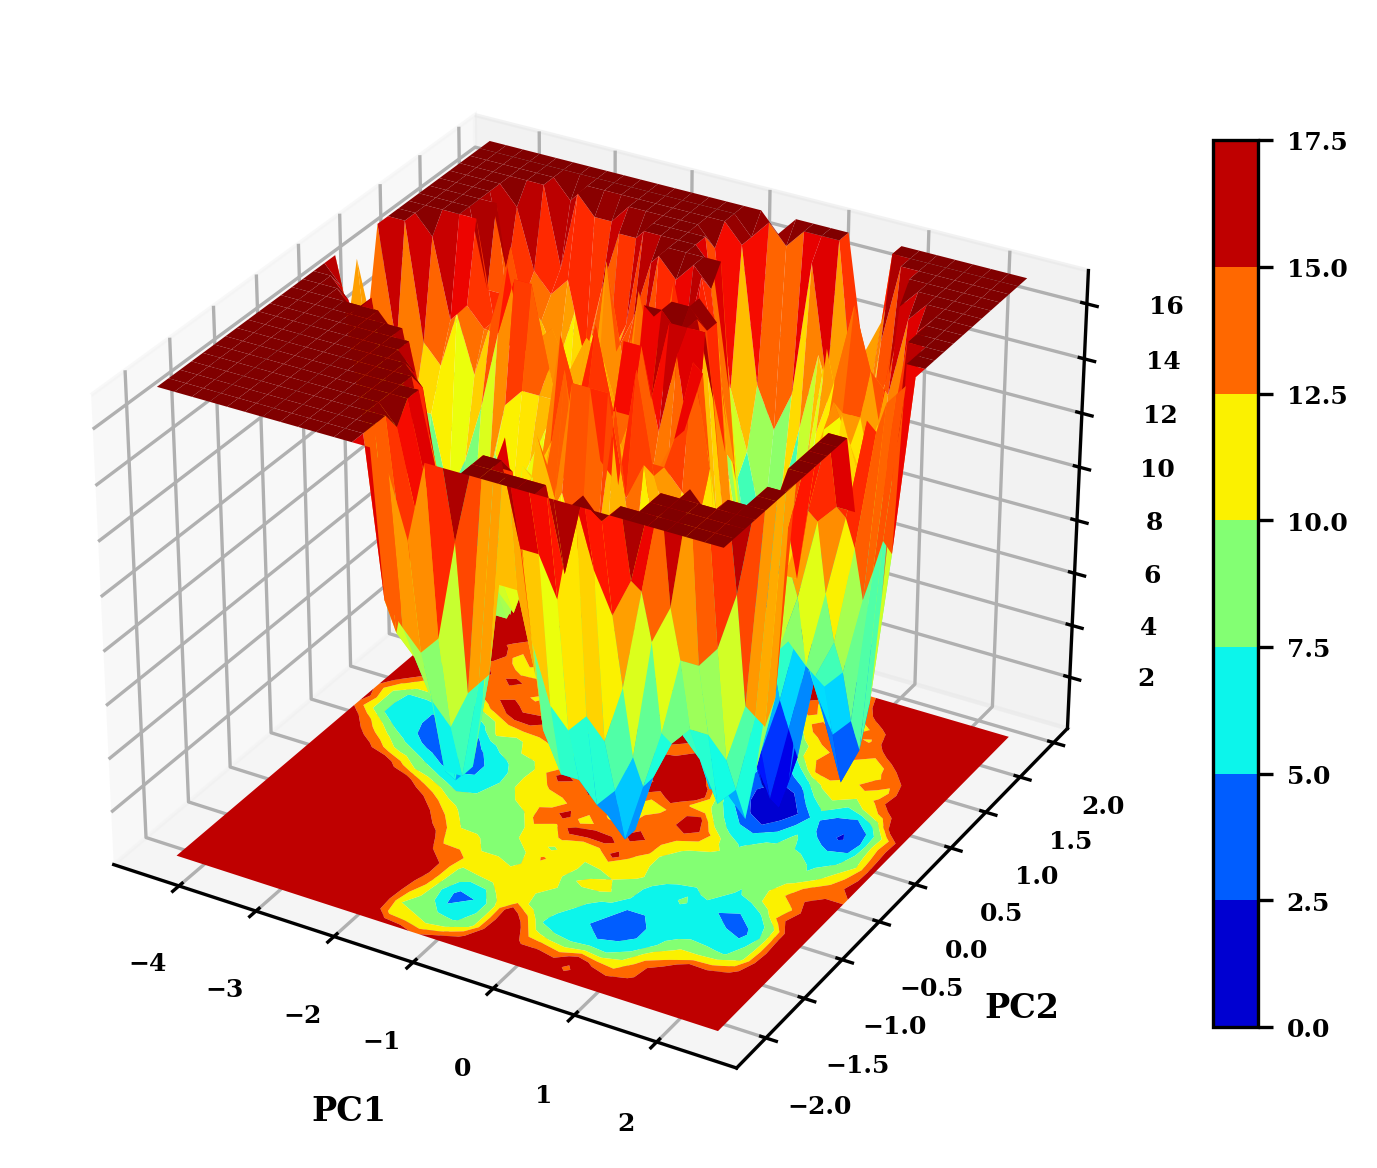

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from scipy.interpolate import griddata
from numpy import linspace
from google.colab import files

# Automatically detect uploaded file name
filename = list(uploaded.keys())[0]
print(f"\n✅ File uploaded: {filename}")

# === User input for output type and DPI ===
file_type = input("\nEnter output file type (e.g., png, tif, pdf): ").strip().lower()
dpi_value = input("Enter DPI value (e.g., 300, 600, 900): ").strip()

# Validate DPI input
try:
    dpi_value = int(dpi_value)
except ValueError:
    dpi_value = 300
    print("⚠️ Invalid DPI entered. Defaulting to 300.")

# === Load data ===
x, y, z = np.loadtxt(filename).T

# === Create 3D Figure ===
fig = plt.figure(dpi=dpi_value)
ax = fig.add_subplot(111, projection='3d')

# Prepare grid
X, Y = np.unique(x), np.unique(y)
xi = linspace(min(X), max(X), len(X))
yi = linspace(min(Y), max(Y), len(Y))
X1, Y1 = np.meshgrid(xi, yi)

# Interpolation
Z = griddata((x, y), z, (X1, Y1), method='nearest')

# --- Compute automatic global vmin/vmax from your interpolated Z ---
z_min = np.nanmin(Z)
z_max = np.nanmax(Z)

# For consistent colors across datasets, do NOT use fixed 0–18
# Use actual min/max from your data:
vmin_plot = z_min
vmax_plot = z_max

# --- Plot smooth surface (no dots, clean like your image) ---
surf = ax.plot_surface(
    X1, Y1, Z,
    rstride=1, cstride=1,
    alpha=1,
    cmap=cm.jet,
    linewidth=0.0,
    antialiased=True,
    vmin=vmin_plot, vmax=vmax_plot
)

# Filled contour projection on Z-plane
cset = ax.contourf(
    X1, Y1, Z,
    zdir='z',
    offset=vmin_plot,
    cmap=cm.jet,
    antialiased=True,
    vmin=vmin_plot, vmax=vmax_plot
)

# --- Axis labels and ticks ---
ax.set_xlabel('PC1', fontsize=8, fontfamily='DejaVu Serif', fontweight='bold')
ax.set_ylabel('PC2', fontsize=8, fontfamily='DejaVu Serif', fontweight='bold')
ax.tick_params(axis="x", labelsize=6)
ax.tick_params(axis="y", labelsize=6)
ax.tick_params(axis="z", labelsize=6)
ax.set_zlim(vmin_plot, vmax_plot)

# Make tick labels bold
for t in ax.get_xticklabels(): t.set_fontweight('bold')
for t in ax.get_yticklabels(): t.set_fontweight('bold')
for t in ax.get_zticklabels(): t.set_fontweight('bold')

# --- Colorbar (auto-scale, clean, no fixed ticks) ---
cbar = fig.colorbar(
    cset,
    shrink=0.6,
    aspect=20,
    extend='neither'
)
cbar.ax.tick_params(labelsize=6) # Reduce numerical label size for colorbar further

# Make colorbar tick labels bold
for t in cbar.ax.get_yticklabels(): t.set_fontweight('bold')

# === Save and Download ===
output_filename = f"3D-FEL_plot.{file_type}"
plt.savefig(output_filename, dpi=dpi_value, bbox_inches='tight')
files.download(output_filename)

print(f"\n✅ Plot saved and downloaded as: {output_filename}")

In [3]:
# ==========================================
# 🔥 Find TOP 3 LOWEST ENERGY MINIMA
# ==========================================

# Flatten Z and remove NaNs
Z_flat = Z.flatten()
valid_idx = ~np.isnan(Z_flat)

Z_valid = Z_flat[valid_idx]

# Get indices of 3 lowest values
top_n = 3
lowest_indices_flat = np.argsort(Z_valid)[:top_n]

# Convert back to original indices
valid_positions = np.where(valid_idx)[0]
lowest_indices = valid_positions[lowest_indices_flat]

# Convert flat indices to 2D indices
min_positions = [np.unravel_index(idx, Z.shape) for idx in lowest_indices]

print("\n✅ Top 3 Lowest Energy Minima:\n")

# Loop through minima
for i, pos in enumerate(min_positions):
    i_idx, j_idx = pos

    min_energy = Z[i_idx, j_idx]
    min_pc1 = X1[i_idx, j_idx]
    min_pc2 = Y1[i_idx, j_idx]

    print(f"🔹 Min {i+1}")
    print(f"Energy: {min_energy:.4f}")
    print(f"PC1: {min_pc1:.4f}, PC2: {min_pc2:.4f}")

    # ==========================================
    # 🔥 Find corresponding time frames
    # ==========================================

    tol = 0.05  # tolerance (adjust if needed)

    mask = (np.abs(x - min_pc1) < tol) & (np.abs(y - min_pc2) < tol)

    frames = np.where(mask)[0]

    if len(frames) > 0:
        print(f"Frames (first 10): {frames[:10]}")
        print(f"Total frames: {len(frames)}")
    else:
        print("⚠️ No frames found (increase tolerance)")

    print("-" * 40)


✅ Top 3 Lowest Energy Minima:

🔹 Min 1
Energy: 0.0000
PC1: 0.9194, PC2: 0.3685
Frames (first 10): [632]
Total frames: 1
----------------------------------------
🔹 Min 2
Energy: 0.7160
PC1: 0.6994, PC2: 0.3685
Frames (first 10): [631]
Total frames: 1
----------------------------------------
🔹 Min 3
Energy: 0.7160
PC1: 0.6994, PC2: 0.4975
Frames (first 10): [663]
Total frames: 1
----------------------------------------
